<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2Fmobilenetv2/notebook/02_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MobileNetV2 – Brain Tumor MRI Classification**


---
This notebook implements a MobileNetV2 model for supervised classification of brain MRI images into four classes:
- 0 – Glioma
- 1 – Meningioma
- 2 – No Tumor
- 3 – Pituitary


The experiment uses the common dataset split prepared for the group:
- 4,480 training images
- 1,120 validation images
- 1,600 test images

The model uses 224 × 224 RGB images with MobileNetV2-specific preprocessing. The same shared dataset split is used for training, validation and final testing. The best model is selected using validation accuracy and is evaluated on the untouched test set using accuracy, precision, recall, F1-score and a confusion matrix.

All MobileNetV2 models, reports, graphs and evaluation files are saved automatically in the group's Results/MobileNetV2 folder.

# **1. Environment and Configuration**

This section connects Google Drive, checks the TensorFlow/GPU environment, sets the random seed, and defines the shared paths and training settings.

In [12]:
import os
import random
import numpy as np
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# Reproducibility
tf.keras.utils.set_random_seed(42)

# Shared project paths
PROJECT_PATH = "/content/drive/MyDrive/SE4050_DL_Assignment"
DATASET_ROOT = os.path.join(PROJECT_PATH, "Dataset")
DATASET_PATH = os.path.join(DATASET_ROOT, "dataset")
SPLITS_PATH = os.path.join(DATASET_PATH, "splits")

# MobileNetV2 results folder
RESULTS_DIR = os.path.join(
    PROJECT_PATH,
    "Results",
    "MobileNetV2"
)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Model paths
MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "mobilenetv2.keras"
)

BEST_MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "mobilenetv2_best.keras"
)

print("\nResults folder ready:")
print(RESULTS_DIR)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Results folder ready:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2


In [13]:
from google.colab import drive

drive.mount("/content/drive")

ValueError: Mountpoint must not already contain files

In [14]:
!rm -rf /content/drive

In [16]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


**Verify the project folders**

In [17]:
print("Dataset root exists:", os.path.isdir(DATASET_ROOT))
print("Dataset folder exists:", os.path.isdir(DATASET_PATH))
print("Splits folder exists:", os.path.isdir(SPLITS_PATH))
print("Results folder exists:", os.path.isdir(RESULTS_DIR))

print("\nDataset root contents:")
print(os.listdir(DATASET_ROOT))

Dataset root exists: True
Dataset folder exists: True
Splits folder exists: True
Results folder exists: True

Dataset root contents:
['dataset_config.py', 'dataset']


# **2. Load and Verify the Common Dataset Split**

The CSV files prepared by the group are used directly. No new random train/validation split is created in this notebook.

In [18]:
import pandas as pd

print("Split files:")
print(os.listdir(SPLITS_PATH))

train_df = pd.read_csv(os.path.join(SPLITS_PATH, "train.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_PATH, "val.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_PATH, "test.csv"))

print("\nTraining images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nColumn names:", train_df.columns.tolist())

print("\nFirst 5 training records:")
print(train_df.head())

Split files:
['train.csv', 'val.csv', 'test.csv', 'test.gsheet', 'train.gsheet']

Training images: 4480
Validation images: 1120
Test images: 1600

Column names: ['filepath', 'label', 'class_name']

First 5 training records:
                           filepath  label class_name
0  Training/pituitary/Tr-pi_135.jpg      3  Pituitary
1    Training/notumor/Tr-no_154.jpg      2   No Tumor
2     Training/glioma/Tr-gl_365.jpg      0     Glioma
3  Training/pituitary/Tr-pi_125.jpg      3  Pituitary
4     Training/glioma/Tr-gl_433.jpg      0     Glioma


In [19]:
CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

print("Training class distribution:")
print(train_df.groupby(["label", "class_name"]).size())

print("\nValidation class distribution:")
print(val_df.groupby(["label", "class_name"]).size())

print("\nTest class distribution:")
print(test_df.groupby(["label", "class_name"]).size())

# Check train/validation/test path overlap
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("\nTrain/Validation overlap:", len(train_paths & val_paths))
print("Train/Test overlap:", len(train_paths & test_paths))
print("Validation/Test overlap:", len(val_paths & test_paths))

Training class distribution:
label  class_name
0      Glioma        1120
1      Meningioma    1120
2      No Tumor      1120
3      Pituitary     1120
dtype: int64

Validation class distribution:
label  class_name
0      Glioma        280
1      Meningioma    280
2      No Tumor      280
3      Pituitary     280
dtype: int64

Test class distribution:
label  class_name
0      Glioma        400
1      Meningioma    400
2      No Tumor      400
3      Pituitary     400
dtype: int64

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


# **3. Inspect an MRI Image**

A sample image is checked to confirm that the CSV path correctly points to the stored MRI image.

Relative path: Training/pituitary/Tr-pi_135.jpg
Full path: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/Training/pituitary/Tr-pi_135.jpg
Image exists: True
Image size: (512, 512)
Image mode: RGB


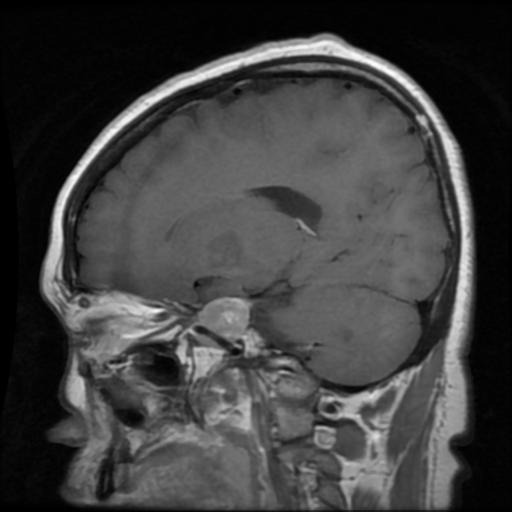

In [20]:
from PIL import Image

relative_path = train_df.iloc[0]["filepath"]
image_path = os.path.join(DATASET_PATH, relative_path)

print("Relative path:", relative_path)
print("Full path:", image_path)
print("Image exists:", os.path.isfile(image_path))

if os.path.isfile(image_path):
    with Image.open(image_path) as img:
        print("Image size:", img.size)
        print("Image mode:", img.mode)
        display(img.copy())
else:
    print("ERROR: Image not found. Check the Dataset path.")

# **4. MobileNetV2 Data Preprocessing**

Images are resized to 224 × 224 × 3 and processed using the preprocessing required by MobileNetV2.
The dataset uses the shared CSV paths, so the same images are used by all four group models.

In [21]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
MAX_EPOCHS = 10
LEARNING_RATE = 0.0001

def load_and_preprocess_image(filepath, label):

    if isinstance(filepath, bytes):
        filepath = filepath.decode("utf-8")

    image_path = os.path.join(DATASET_PATH, filepath)

    img = load_img(
        image_path,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )

    img = img_to_array(img)

    # MobileNetV2-specific preprocessing
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)

    return img.astype(np.float32), label

In [22]:
sample_image = train_df.iloc[0]["filepath"]
sample_label = train_df.iloc[0]["label"]

image, label = load_and_preprocess_image(
    sample_image,
    sample_label
)

print("Image shape:", image.shape)
print("Label:", label)
print("Preprocessed image range:", image.min(), "to", image.max())

Image shape: (224, 224, 3)
Label: 3
Preprocessed image range: -1.0 to 0.99215686


In [23]:
def create_dataset(df, training=False):

    filepaths = df["filepath"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    def process_image(filepath, label):

        image, label = tf.numpy_function(
            load_and_preprocess_image,
            [filepath, label],
            [tf.float32, tf.int64]
        )

        # Set shapes because tf.numpy_function does not preserve them automatically
        image.set_shape([224, 224, 3])
        label.set_shape([])

        return image, label

    dataset = dataset.map(
        process_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [24]:
train_dataset = create_dataset(train_df, training=True)
val_dataset = create_dataset(val_df, training=False)
test_dataset = create_dataset(test_df, training=False)

print("Train dataset created")
print("Validation dataset created")
print("Test dataset created")

Train dataset created
Validation dataset created
Test dataset created


In [25]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First labels:", labels[:5])

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
First labels: tf.Tensor([2 3 1 2 0], shape=(5,), dtype=int64)


# **5. Build MobileNetV2 Model**

The ImageNet-pretrained MobileNetV2 feature extractor is initially frozen. A small classification head is added for the four brain MRI classes.

In [26]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 base model loaded")
print("Base model frozen")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 base model loaded
Base model frozen


In [27]:
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

print("MobileNetV2 classification model created")

MobileNetV2 classification model created


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **6. Compile the Model and Configure Callbacks**
The model uses Adam with the current agreed MobileNetV2 learning rate. The best checkpoint is selected using validation accuracy, and early stopping restores the best validation weights.

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

print("Callbacks created successfully")
print("Best model path:")
print(BEST_MODEL_PATH)

Callbacks created successfully
Best model path:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2_best.keras


# **7. Train MobileNetV2**
Training uses the common training and validation split. The test set is not used during training.

In [31]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    callbacks=[
        checkpoint,
        early_stop
    ]
)

Epoch 1/10
279/280 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5600 - loss: 1.0597
Epoch 1: val_accuracy improved from None to 0.85000, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2_best.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.6913 - loss: 0.7781 - val_accuracy: 0.8500 - val_loss: 0.4483
Epoch 2/10
278/280 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8386 - loss: 0.4648
Epoch 2: val_accuracy improved from 0.85000 to 0.86339, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2_best.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8411 - loss: 0.4399 - val_accuracy: 0.8634 - val_loss: 0.3842
Epoch 3/10
280/280 ━━━━━━━━━━━

In [32]:
# Explicitly load the best checkpoint before final evaluation
model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Save a copy as the final MobileNetV2 model
model.save(MODEL_PATH)

print("Best MobileNetV2 model loaded and saved")
print("Best model:", BEST_MODEL_PATH)
print("Final model:", MODEL_PATH)

Best MobileNetV2 model loaded and saved
Best model: /content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2_best.keras
Final model: /content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/mobilenetv2.keras


# **8. Save Training History and Training Curves**

In [33]:
history_df = pd.DataFrame(history.history)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print("Training history saved:")
print(HISTORY_PATH)

Training history saved:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_training_history.csv


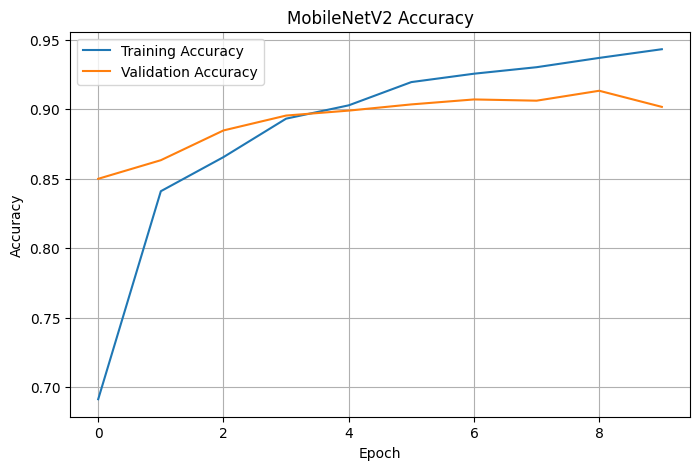

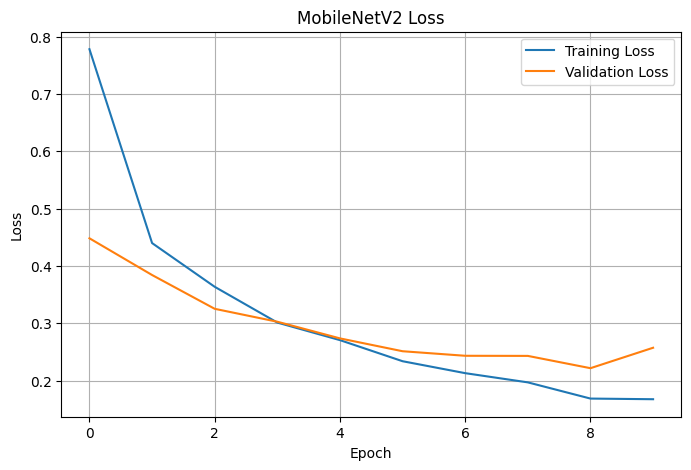

Training graphs saved
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_accuracy.png
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_loss.png


In [34]:
import matplotlib.pyplot as plt

ACCURACY_PLOT = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_accuracy.png"
)

LOSS_PLOT = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_loss.png"
)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(ACCURACY_PLOT, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(LOSS_PLOT, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Training graphs saved")
print(ACCURACY_PLOT)
print(LOSS_PLOT)

# **9. Final Evaluation on the Unseen Test Set**
The final model is evaluated only on the common 1,600-image test set.

In [35]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 663s 7s/step - accuracy: 0.8756 - loss: 0.4534
Test Loss: 0.4533974826335907
Test Accuracy: 0.8756250143051147
Test Accuracy (%): 87.56250143051147


In [36]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed")
print("Number of predictions:", len(y_pred))

Predictions completed
Number of predictions: 1600


# **10. Classification Report**

In [37]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

REPORT_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_classification_report.csv"
)

report_df.to_csv(
    REPORT_PATH
)

print("\nClassification report saved:")
print(REPORT_PATH)

              precision    recall  f1-score   support

      Glioma     0.9647    0.6825    0.7994       400
  Meningioma     0.7468    0.8775    0.8069       400
    No Tumor     0.9116    0.9800    0.9446       400
   Pituitary     0.9233    0.9625    0.9425       400

    accuracy                         0.8756      1600
   macro avg     0.8866    0.8756    0.8733      1600
weighted avg     0.8866    0.8756    0.8733      1600


Classification report saved:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_classification_report.csv


# **11. Confusion Matrix**

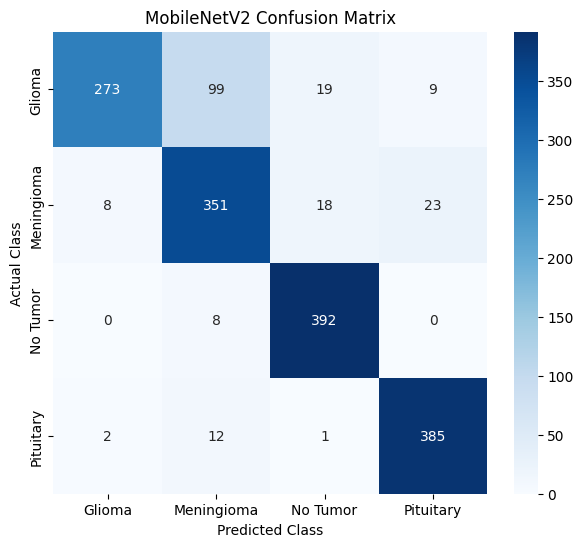

Confusion matrix saved:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_confusion_matrix.png
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_confusion_matrix.csv


In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

CM_PNG_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_confusion_matrix.png"
)

CM_CSV_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_confusion_matrix.csv"
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 Confusion Matrix")
plt.savefig(
    CM_PNG_PATH,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(CM_CSV_PATH)

print("Confusion matrix saved:")
print(CM_PNG_PATH)
print(CM_CSV_PATH)

# **12. Final MobileNetV2 Results**

In [39]:
results = {
    "Model": "MobileNetV2",
    "Test Accuracy": test_accuracy,
    "Test Loss": test_loss,
    "Macro Precision": report_dict["macro avg"]["precision"],
    "Macro Recall": report_dict["macro avg"]["recall"],
    "Macro F1": report_dict["macro avg"]["f1-score"]
}

results_df = pd.DataFrame([results])

FINAL_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_final_results.csv"
)

results_df.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

print(results_df.to_string(index=False))

print("\nFinal results saved successfully:")
print(FINAL_RESULTS_PATH)

      Model  Test Accuracy  Test Loss  Macro Precision  Macro Recall  Macro F1
MobileNetV2       0.875625   0.453397         0.886591      0.875625   0.87334

Final results saved successfully:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_final_results.csv


In [40]:
SETTINGS_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_settings.txt"
)

with open(SETTINGS_PATH, "w") as f:
    f.write("MobileNetV2 Experimental Settings\n")
    f.write("--------------------------------\n")
    f.write("Input size: 224 x 224 RGB\n")
    f.write("Batch size: 16\n")
    f.write("Maximum epochs: 10\n")
    f.write("Random seed: 42\n")
    f.write("Optimizer: Adam\n")
    f.write(f"Learning rate: {LEARNING_RATE}\n")
    f.write("Loss: Sparse categorical cross-entropy\n")
    f.write("Base model: MobileNetV2 pretrained on ImageNet\n")
    f.write("Base model initially frozen: Yes\n")
    f.write("Dropout: 0.3\n")
    f.write("Classes: 4\n")
    f.write("Train images: 4480\n")
    f.write("Validation images: 1120\n")
    f.write("Test images: 1600\n")
    f.write("Checkpoint monitor: val_accuracy\n")
    f.write("Early stopping monitor: val_accuracy\n")
    f.write("Early stopping patience: 3\n")
    f.write("Data augmentation: None in current implementation\n")

print("Settings saved:")
print(SETTINGS_PATH)

Settings saved:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_settings.txt


# **13. Class-wise Analysis and Error Analysis**

This section examines MobileNetV2 performance separately for each MRI class and identifies the main prediction errors.

In [41]:
from sklearn.metrics import precision_recall_fscore_support

# Class-wise precision, recall and F1-score
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    zero_division=0
)

class_metrics_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

print("Class-wise Performance:")
print(class_metrics_df.to_string(index=False))

CLASS_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_class_metrics.csv"
)

class_metrics_df.to_csv(
    CLASS_METRICS_PATH,
    index=False
)

print("\nClass metrics saved:")
print(CLASS_METRICS_PATH)

Class-wise Performance:
     Class  Precision  Recall  F1-Score  Support
    Glioma   0.964664  0.6825  0.799414      400
Meningioma   0.746809  0.8775  0.806897      400
  No Tumor   0.911628  0.9800  0.944578      400
 Pituitary   0.923261  0.9625  0.942472      400

Class metrics saved:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_class_metrics.csv


In [42]:
# Create a row-by-row prediction table for error analysis
error_rows = []

for i, row in test_df.reset_index(drop=True).iterrows():
    true_label = int(y_true[i])
    predicted_label = int(y_pred[i])

    error_rows.append({
        "filepath": row["filepath"],
        "true_label": true_label,
        "true_class": CLASS_NAMES[true_label],
        "predicted_label": predicted_label,
        "predicted_class": CLASS_NAMES[predicted_label],
        "correct": true_label == predicted_label
    })

error_analysis_df = pd.DataFrame(error_rows)

print("Total test images:", len(error_analysis_df))
print("Correct predictions:", int(error_analysis_df["correct"].sum()))
print("Incorrect predictions:", int((~error_analysis_df["correct"]).sum()))

print("\nIncorrect predictions by actual class:")
print(
    error_analysis_df[~error_analysis_df["correct"]]
    .groupby("true_class")
    .size()
    .sort_values(ascending=False)
)

ERROR_ANALYSIS_PATH = os.path.join(
    RESULTS_DIR,
    "MobileNetV2_error_analysis.csv"
)

error_analysis_df.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False
)

print("\nError analysis saved:")
print(ERROR_ANALYSIS_PATH)

Total test images: 1600
Correct predictions: 1401
Incorrect predictions: 199

Incorrect predictions by actual class:
true_class
Glioma        127
Meningioma     49
Pituitary      15
No Tumor        8
dtype: int64

Error analysis saved:
/content/drive/MyDrive/SE4050_DL_Assignment/Results/MobileNetV2/MobileNetV2_error_analysis.csv


In [43]:
# Identify the most common class-to-class misclassifications
confusion_pairs = (
    error_analysis_df[~error_analysis_df["correct"]]
    .groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("Most common misclassifications:")
print(confusion_pairs.to_string(index=False))

Most common misclassifications:
true_class predicted_class  Count
    Glioma      Meningioma     99
Meningioma       Pituitary     23
    Glioma        No Tumor     19
Meningioma        No Tumor     18
 Pituitary      Meningioma     12
    Glioma       Pituitary      9
Meningioma          Glioma      8
  No Tumor      Meningioma      8
 Pituitary          Glioma      2
 Pituitary        No Tumor      1
